## 1. 去噪处理 架构

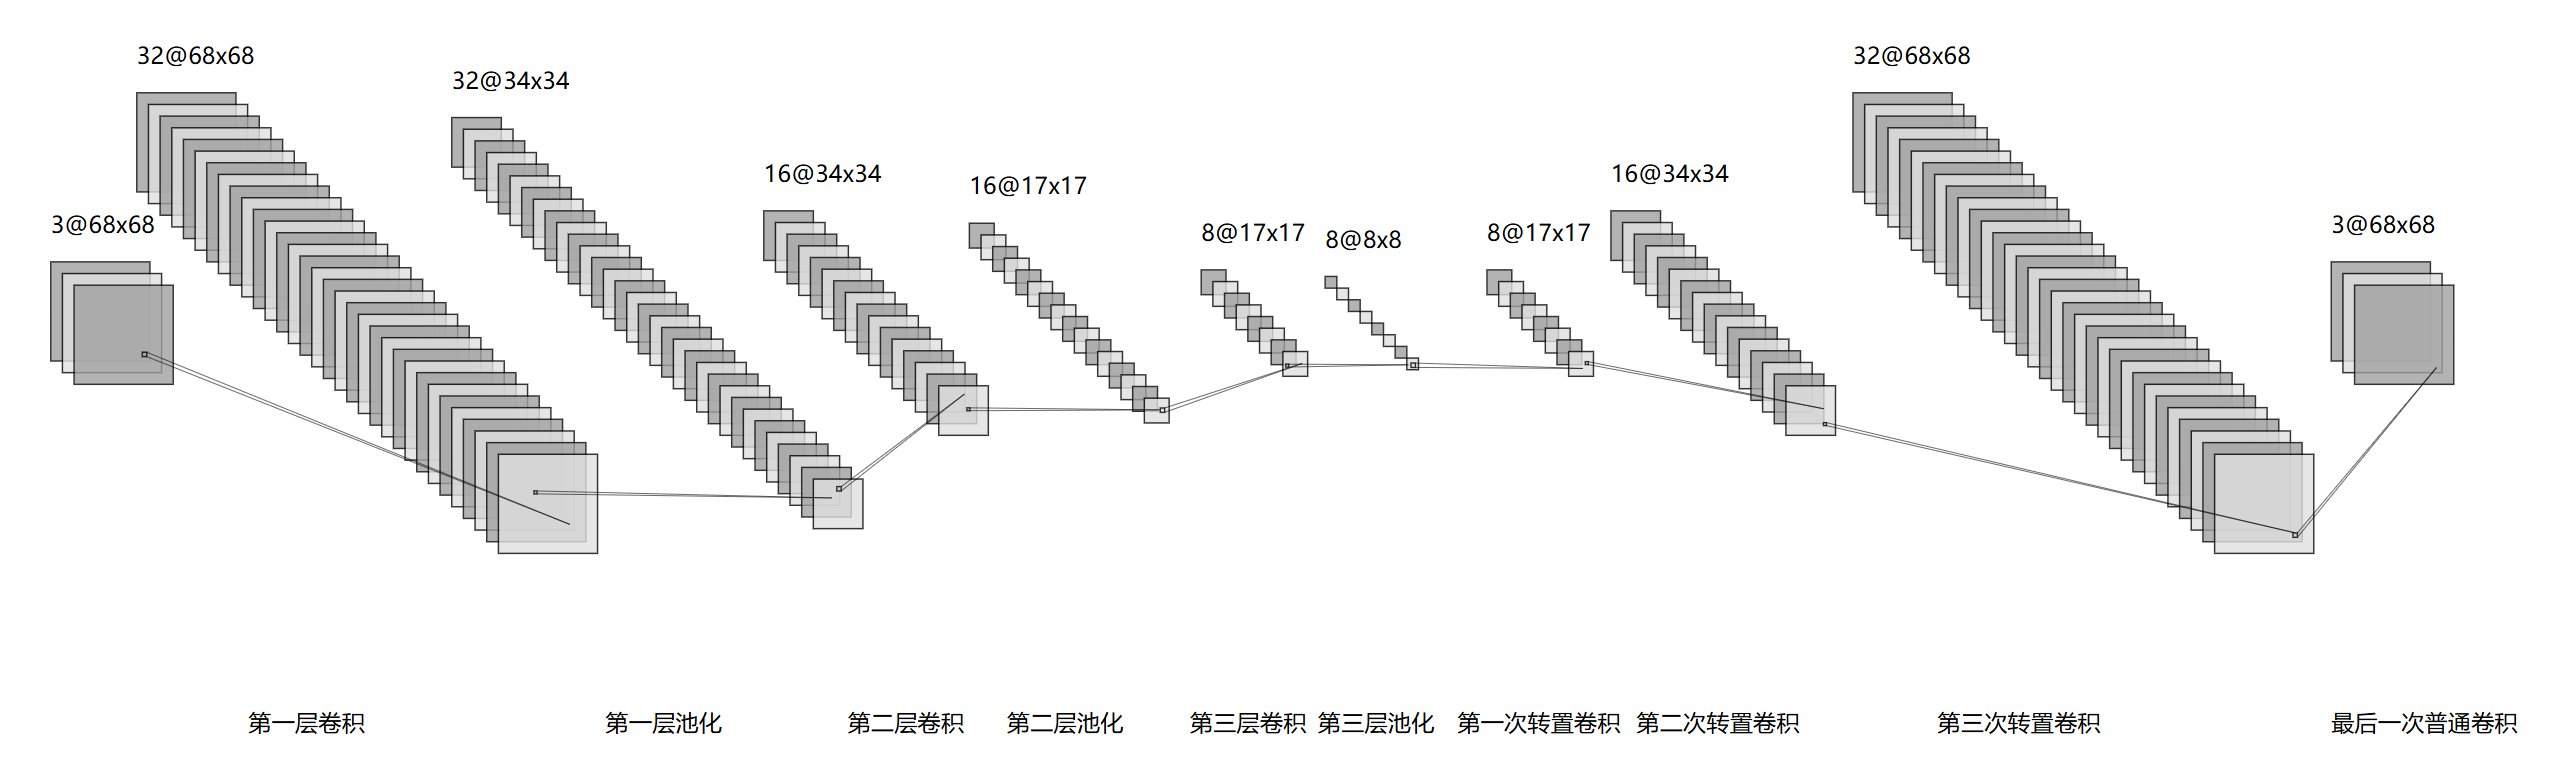

In [ ]:
## 2. 导入依赖

In [ ]:
from os import listdir
from os.path import abspath, join
import matplotlib.pyplot as plt
from PIL.Image import open as pil_open
from torch import rand, device, cuda, save, load, rand_like, Tensor, relu
from torch.nn import Module, Conv2d, MaxPool2d, ConvTranspose2d, MSELoss
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import Compose, Resize, ToTensor
from tqdm import tqdm

## 3. 定义数据处理类

### 3.1 定义图片处理类

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, image_dir: str, transform: Compose = None, noisy_factor: float = 0.3):
        self.image_dir = abspath(path=image_dir)
        self.transform = transform
        self.noisy_factor = noisy_factor
        self.name_list = listdir(path=self.image_dir)

    def __len__(self):
        return len(self.name_list)
    
    def __getitem__(self, index: int) -> Tensor:
        image_path = join(self.image_dir, self.name_list[index])     # 获取图片路径
        image = pil_open(image_path).convert(mode="RGB")             # 打开图片并转换为RGB模式
        
        if self.transform:
            image_tensor = self.transform(image)                     # 应用数据处理变换
        else:
            raise ValueError("No transform defined")                 # 如果没有定义数据处理变换，则抛出异常

        noisy_tensor = image_tensor + self.noisy_factor * rand_like(image_tensor)  # 添加噪声
        processed_tensor = noisy_tensor.clamp(min=0.0, max=1.0)      # 将噪声图像的像素值限制在 0 到 1 之间
        
        return processed_tensor, image_tensor

### 3.2 加载图片数据

In [ ]:
def load_image_data(image_dir: str, height: int = 68, width: int = 68,
                    train_ratio: float = 0.75, batch_size: int = 32) -> Dataset:
    resize = Resize(size=(height, width))                                # 调整图片大小
    transforms = [resize, ToTensor()]                                    # 定义转换操作
    image_transform = Compose(transforms=transforms)                     # 创建转换操作

    image_dataset = ImageDataset(image_dir=image_dir, transform=image_transform)
    train_dataset, valid_dataset = random_split(dataset=image_dataset, lengths=[train_ratio, 1 - train_ratio])
    
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_loader = DataLoader(dataset=valid_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
    return train_loader, valid_loader

### 3.3 测试数据集

In [ ]:
train_loader, valid_loader = load_image_data(image_dir="../data/dataset", height=64,
                                             width=64, train_ratio=0.75, batch_size=32)

print(f"训练数据集的长度： {len(train_loader)}")
print(f"验证数据集的长度： {len(valid_loader)}")

## 4. 自定义神经网络

In [ ]:
class DeNoisyConv(Module):

    def __init__(self):
        super().__init__()

        # 定义三个卷积层
        self.conv1 = Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv3 = Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1)

        # 定义池化层
        self.pool = MaxPool2d(kernel_size=2, stride=2, padding=0)

        # 定义三个转置卷积层
        self.deconv1 = ConvTranspose2d(in_channels=8, out_channels=8, kernel_size=3, stride=2, padding=0, output_padding=0)
        self.deconv2 = ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=2, stride=2, padding=0, output_padding=0)
        self.deconv3 = ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=2, stride=2, padding=0, output_padding=0)

        # 定义普通卷积层
        self.conv_out = Conv2d(in_channels=32, out_channels=3, kernel_size=3, stride=1, padding=1)
        
    def forward(self, input: Tensor):
        # 编码阶段
        x = self.conv1(input)
        x = relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = relu(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = relu(x)
        x = self.pool(x)
        
        # 解码阶段
        x = self.deconv1(x)
        x = relu(x)
        x = self.deconv2(x)
        x = relu(x)
        x = self.deconv3(x)
        x = relu(x)
        output = self.conv_out(x)
        
        return output

## 4.2 查看模型

In [ ]:
test_model = DeNoisyConv()
print(test_model)

x = rand(1, 3, 68, 68)
y = test_model.forward(x)
print(y.shape)


## 5. 模型训练

### 5.1

In [ ]:
def train_model(model: DeNoisyConv, model_path: str, train_loader: DataLoader, loss_fn: MSELoss,
                optimizer: Adam, device: device = device("cpu"), epochs: int = 10):
    model.to(device=device)
    model.train()

    train_loss_list = []
    bar = tqdm(iterable=range(epochs), desc="Training", unit="epoch", colour="green")
    for epoch in bar:
        train_loss = 0.0
        for noisy_image, target_image in train_loader:
            noisy_image = noisy_image.to(device=device)
            target_image = target_image.to(device=device)

            predict_image = model.forward(input=noisy_image)
            loss_value = loss_fn(predict_image, target_image)
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_loss += loss_value.item()

        average_train_loss = train_loss / len(train_loader)
        train_loss_list.append(average_train_loss)
        
        bar.set_description(f"Training (Loss: {average_train_loss:.4f})")
        bar.set_postfix(train_loss=average_train_loss)

    save(obj=model.state_dict(), f=model_path)
    print(f"Model saved to '{model_path}'")
    
    return train_loss_list

## 6. 运行代码

### 6.1 参数设置和模型训练

In [ ]:
learning_rate = 0.01
batch_size = 32
height = 68
width = 68
train_ratio = 0.75
epochs = 10

model_path="../data/de-noisy.pth"
DEVICE = device("cuda" if cuda.is_available() else "cpu")

train_loader, valid_loader = load_image_data(image_dir="../data/dataset", height=height, width=width,
                                             train_ratio=train_ratio, batch_size=batch_size)
model = DeNoisyConv()
loss_fn = MSELoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

train_loss_list = train_model(model=model, model_path=model_path, train_loader=train_loader,
                              loss_fn=loss_fn, optimizer=optimizer, device=DEVICE, epochs=epochs)

### 6.2 查看损失

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_list, label="Train Loss", color="red", linestyle="-", marker="o", markersize=5)
plt.title("Training Loss")
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 7. 查看结果

### 7.1 准备数据

In [ ]:
test_iterable = iter(valid_loader)
noisy_images, origin_images = next(test_iterable)

input_data = noisy_images.to(device=DEVICE)

valid_model = DeNoisyConv()
state_dict = load(f=model_path)
valid_model.load_state_dict(state_dict=state_dict)
valid_model.eval()

predict_images = valid_model.forward(input=input_data)

noisy_array = noisy_images.permute(0, 2, 3, 1).cpu().numpy()
origin_array = origin_images.permute(0, 2, 3, 1).cpu().numpy()
predict_array = predict_images.permute(0, 2, 3, 1).detach().cpu().numpy()

### 7.2 画图查看

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(25, 4), sharex=True, sharey=True)

for images, row in zip([noisy_array, predict_array, origin_array], axes):
    for image, ax in zip(images, row):
        ax.imshow(image)
        ax.axis("off")

plt.show()